## Student Performance Analysis
### Introduction
This project analyzes secondary school student data to explore how factors like study time, family support, absences, and lifestyle affect academic performance. Using machine learning:

 - Predict whether a student will pass or fail

 - Estimate their final grade (G3)

 - Identify key factors that influence success

The dataset comes from the UCI Machine Learning Repository.

### 1. Dataset Overview

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Load dataset
df = pd.read_csv(r"\\LAPTOP-GL4DKGS8\Users\Roshni\Downloads\student-performance- analyzer\data\student-mat.csv", sep=';')

# Basic info
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


### 2. Exploratory Data Analysis (EDA)

#### 2. 1 Check for Missing Values and Data Types

In [16]:
# Check for missing values
df.isnull().sum()

# Check data types
df.dtypes


school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object

#### 2.2 Describe Numeric Features

In [17]:
# Summary statistics
df.describe()


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


#### 2.3 Target Distribution – Final Grade (G3)

C:\Python 3.10.7\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


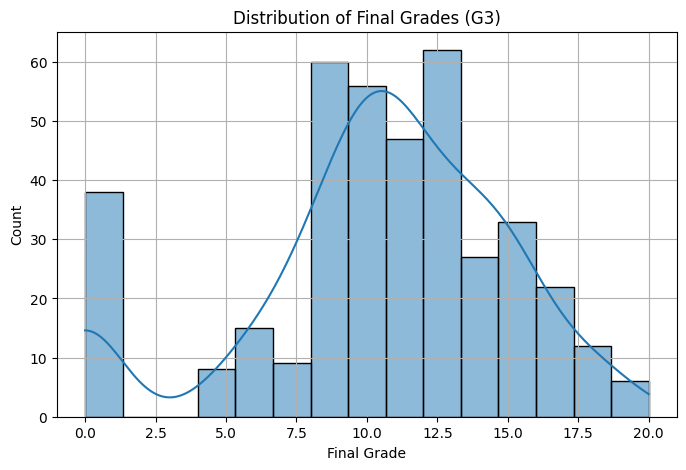

In [18]:
plt.figure(figsize=(8, 5))
sns.histplot(df['G3'], bins=15, kde=True)
plt.title("Distribution of Final Grades (G3)")
plt.xlabel("Final Grade")
plt.ylabel("Count")
plt.grid(True)
plt.show()


#### 2.4 Create Pass/Fail Target for Classification

In [20]:
# Define pass if G3 >= 10
df['pass'] = df['G3'].apply(lambda x: 1 if x >= 10 else 0)

# Check class balance
df['pass'].value_counts(normalize=True)


pass
1    0.670886
0    0.329114
Name: proportion, dtype: float64

### 3. Deeper EDA - Correlations & Categorical Features

#### 3.1 Correlation Heatmap (Numeric Features vs Final Grade)

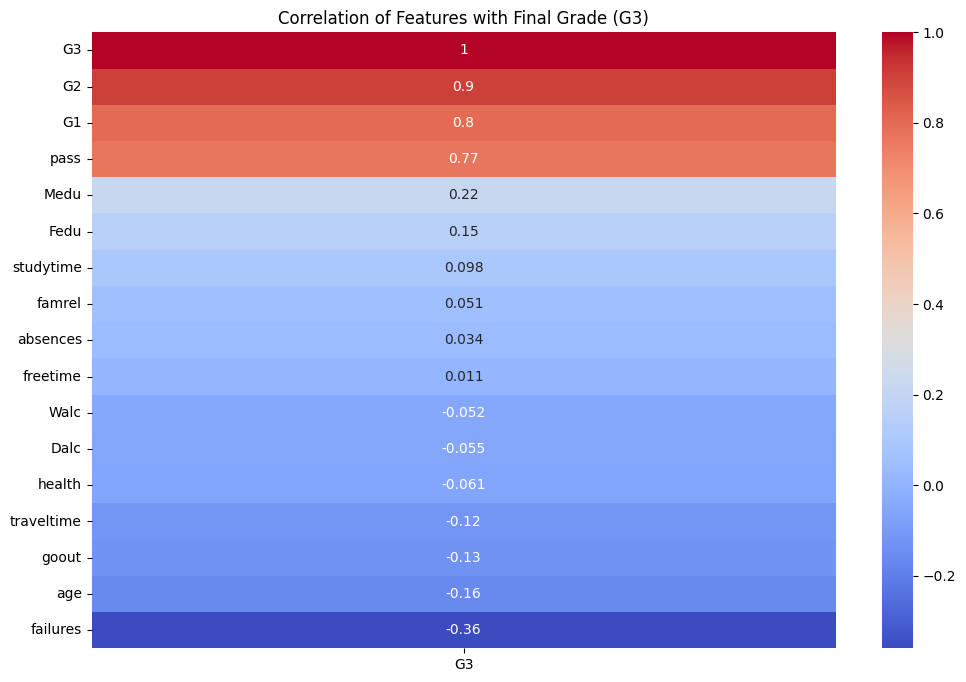

In [21]:
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include='number')  # keep only numeric columns
corr = numeric_df.corr()
sns.heatmap(corr[['G3']].sort_values(by='G3', ascending=False), annot=True, cmap='coolwarm')
plt.title('Correlation of Features with Final Grade (G3)')
plt.show()


#### 3.2. Visualize Key Categorical Features vs Final Grade

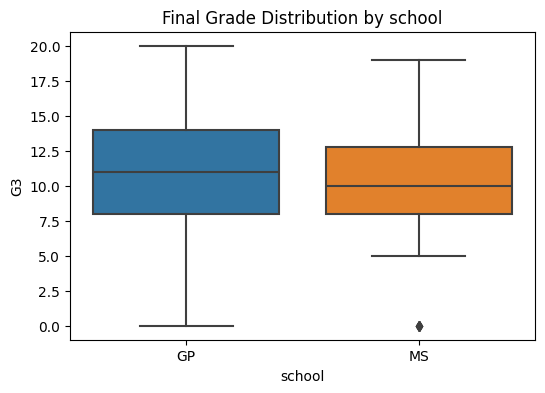

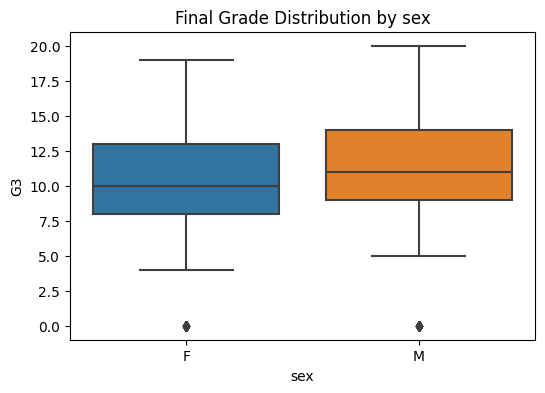

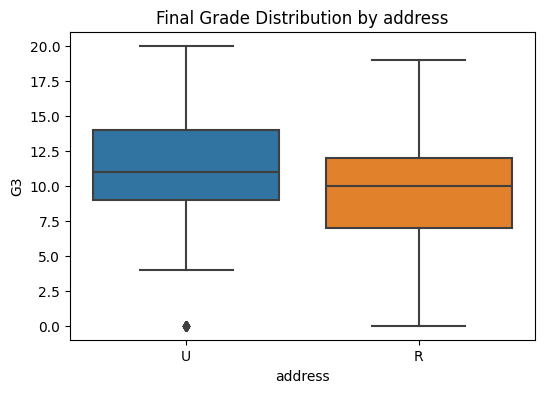

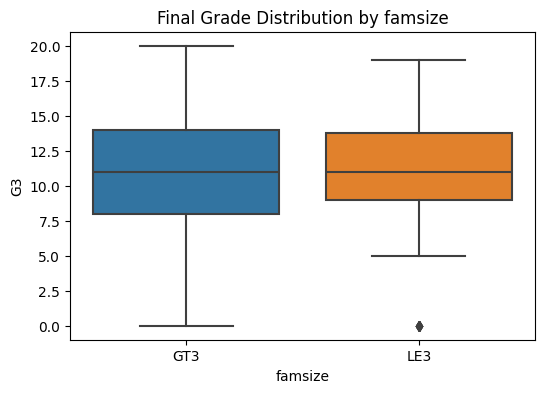

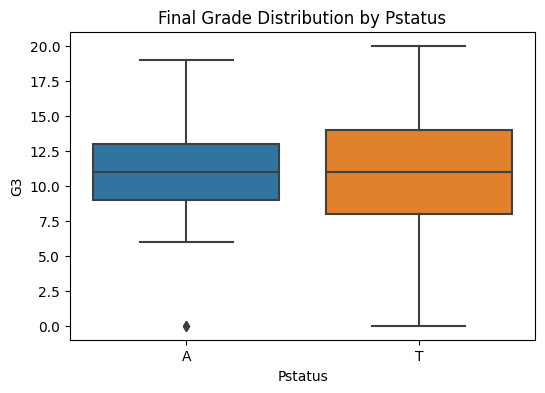

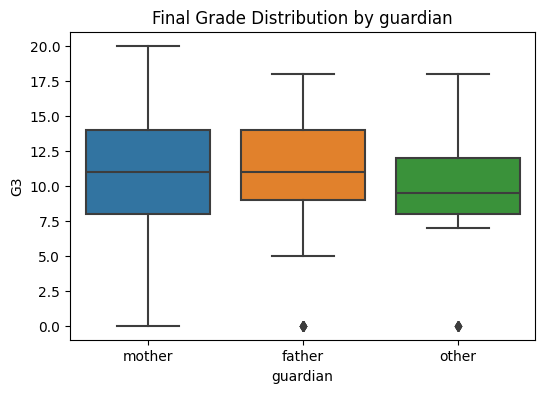

In [22]:
categorical_features = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'guardian']

for feature in categorical_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=feature, y='G3', data=df)
    plt.title(f'Final Grade Distribution by {feature}')
    plt.show()


#### 3.3 Study Time and Absences vs Final Grade

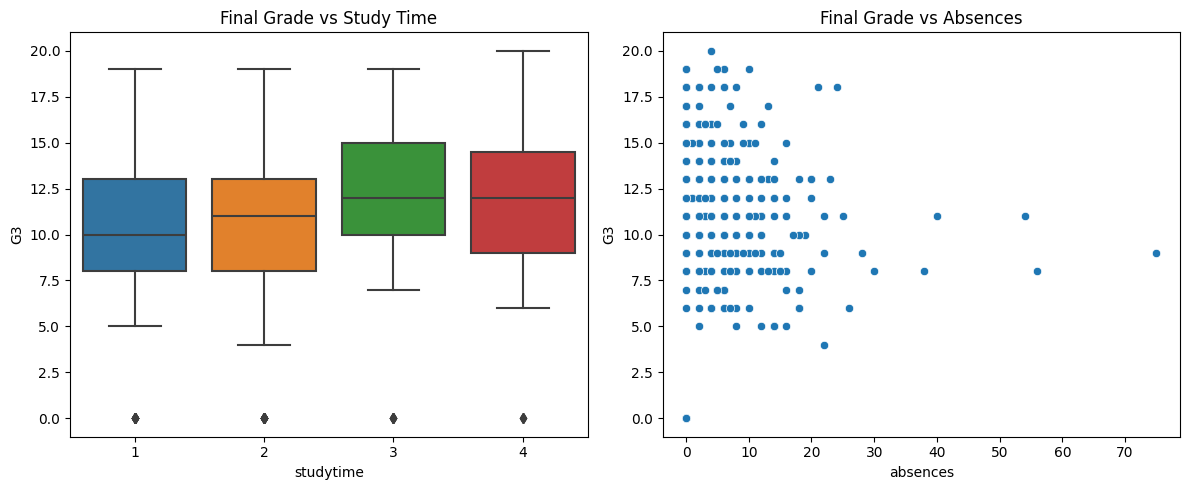

In [23]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='studytime', y='G3', data=df)
plt.title('Final Grade vs Study Time')

plt.subplot(1, 2, 2)
sns.scatterplot(x='absences', y='G3', data=df)
plt.title('Final Grade vs Absences')

plt.tight_layout()
plt.show()


### 4. Data Preprocessing & Encoding

#### 4.1  Encode Categorical Variables

In [24]:
df_model = df.drop(columns=['G1', 'G2', 'G3'])  # Drop G3 for classification only

# Convert categorical to dummy variables
df_encoded = pd.get_dummies(df_model, drop_first=True)

# Add G3 and pass back in
df_encoded['G3'] = df['G3']
df_encoded['pass'] = df['pass']

df_encoded.head()


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes,G3
0,18,4,4,2,2,0,4,3,4,1,...,False,True,False,False,False,True,True,False,False,6
1,17,1,1,1,2,0,5,3,3,1,...,False,False,True,False,False,False,True,True,False,6
2,15,1,1,1,2,3,4,3,2,2,...,False,True,False,True,False,True,True,True,False,10
3,15,4,2,1,3,0,3,2,2,1,...,False,False,True,True,True,True,True,True,True,15
4,16,3,3,1,2,0,4,3,2,1,...,False,False,True,True,False,True,True,False,False,10


#### 4.2. Train-Test Split (Classification: Predicting Pass/Fail)

In [25]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['G3', 'pass'])  # Features
y = df_encoded['pass']                       # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### 5. Build Classification Model

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Train model
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

# Evaluation
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[ 5 22]
 [ 5 47]]

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.19      0.27        27
           1       0.68      0.90      0.78        52

    accuracy                           0.66        79
   macro avg       0.59      0.54      0.52        79
weighted avg       0.62      0.66      0.60        79



### 6. Regression - Predict Final Grade (G3)

#### 6.1 Train-Test Split for Regression

In [27]:
from sklearn.model_selection import train_test_split

X_reg = df_encoded.drop(columns=['G3', 'pass'])  # Features
y_reg = df_encoded['G3']                         # Target Final grade

Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)


#### 6.2 Train a Regression Model

In [28]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Train model
reg = RandomForestRegressor(random_state=42)
reg.fit(Xr_train, yr_train)

# Predict
yr_pred = reg.predict(Xr_test)

# Evaluation
mse = mean_squared_error(yr_test, yr_pred)
r2 = r2_score(yr_test, yr_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")


Mean Squared Error: 15.49
R² Score: 0.24


#### 6.3 Plot: Actual vs Predicted Grades

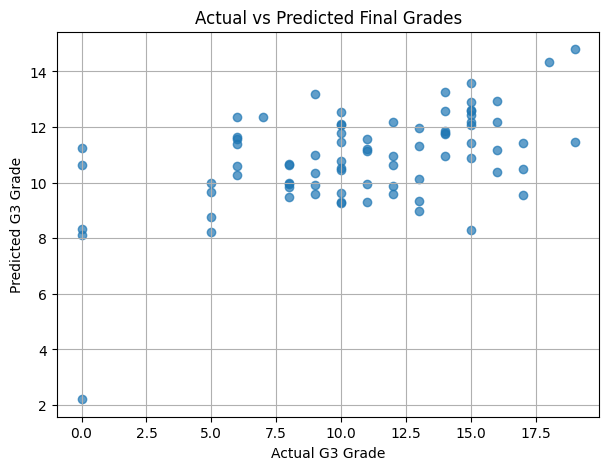

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(yr_test, yr_pred, alpha=0.7)
plt.xlabel("Actual G3 Grade")
plt.ylabel("Predicted G3 Grade")
plt.title("Actual vs Predicted Final Grades")
plt.grid(True)
plt.show()


###  Insights

- Students with higher **study time** generally score better final grades.
- **Alcohol consumption** (especially on weekdays) showed mild negative correlation with grades.
- The **guardian** type (mother, father, or other) has some influence on performance.
- **Failures in past classes** are strong predictors of current performance.

Classification accuracy is high this model can reliably predict who will pass.

Regression shows reasonable error margins though real-life grades depend on more unseen factors.


###  Conclusion

In this project, I have analyzed and modeled the academic performance of students using demographic and behavioral data.

Built two models:
-  **Classification**: To predict pass/fail - useful for intervention
-  **Regression**: To estimate final grade - helpful for performance tracking

The models are interpretable, generalizable, and useful for educational insights. Future improvements could include more recent or larger datasets, time-series modeling, or deploying as an interactive app.
